# Notebook 00 — Preprocessing: Ice Mask, Long-Term Mean Velocities, Mean ADT

**Kinetic Energy Trends and Eddy Saturation in the Southern Ocean**
Cristina Martí-Solana (cmarti@imedea.uib-csic.es)

---

Computes the preprocessing quantities required by the rest of the workflow:

| Quantity | File | Used by |
|---|---|---|
| Permanent ice mask (any JJA day ice-covered → masked) | `outputs/sea_ice_mask.nc` | Notebooks 01–03a, s01–s03 |
| Long-term mean velocities ū_lt, v̄_lt | `outputs/preprocessing.nc` | Notebook 01 (EKE anomalies) |
| Mean ADT | `outputs/mean_adt.nc` | ACC contour mask in Notebooks 02, 03a, 05, s01–s03 |

**Strategy** — two-pass streaming computation (low memory, no dask):

1. **Pass A** — permanent ice mask from winter months (JJA) only: a cell is masked if `flag_ice > 0` on *any* winter day of the study period.
2. **Pass B** — long-term mean geostrophic velocities and mean ADT from *all* months, with the permanent ice mask applied so the same spatial domain is used consistently throughout.

**Input data** — CMEMS gridded L4 altimetry, 0.125°, daily:

| Product ID | Use |
|---|---|
| `SEALEVEL_GLO_PHY_L4_MY_008_047` (all-satellite) | Main analysis |
| `SEALEVEL_GLO_PHY_L4_MY_008_057` (two-satellite) | Robustness check (Notebook S3) |


## 1. Setup and Imports

In [1]:
import os
import sys
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy import feature as cfeature

# ── Copernicus Marine Toolbox (optional, required for remote access) ──
try:
    import copernicusmarine
    _CMEMS_AVAILABLE = True
except ImportError:
    _CMEMS_AVAILABLE = False
    print("WARNING: copernicusmarine not installed — remote access unavailable.")
    print("         Install with:  pip install copernicusmarine")

# Authenticate once — credentials are cached for the rest of the session.
# On first ever run you will be prompted; after that the stored token is reused.
if _CMEMS_AVAILABLE:
    copernicusmarine.login()

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

print(f"Repository root: {REPO_ROOT}")
print(f"Copernicus Marine Toolbox available: {_CMEMS_AVAILABLE}")
print("Imports OK.")

.venv-1/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO - 2026-07-06T05:35:16Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:Copernicus Marine password:File ~/.copernicusmarine/.copernicusmarine-credentials already exists, overwrite it ? [y/N]:

INFO - 2026-07-06T05:35:47Z - Credentials file stored in ~/.copernicusmarine/.copernicusmarine-credentials.


Repository root: repository
Copernicus Marine Toolbox available: True
Imports OK.


## 2. Configuration

Data source (local `$ALTIMETRY_DIR` or remote CMEMS streaming), processing region, study period, and output paths.

In [2]:
# ── Remote data access (Copernicus Marine Toolbox) ──────────────────────────
# Set USE_REMOTE_DATA = True  to stream data directly from CMEMS servers
# without storing files locally.  Requires the copernicusmarine package and a
# valid CMEMS account (free registration: https://data.marine.copernicus.eu/register).
# On first run you will be prompted for credentials; they are cached automatically.
# Set USE_REMOTE_DATA = False to read from a local directory tree (INPUT_DIR).
USE_REMOTE_DATA  = True

# Copernicus Marine dataset ID for the DUACS all-satellite MY L4 product
# (SEALEVEL_GLO_PHY_L4_MY_008_047).  Change to the two-sat ID below if needed:
#   two-sat: \"cmems_obs-sl_glo_phy-ssh_my_twosat-l4-duacs-0.125deg_P1D\"
DATASET_ID       = "cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D"
REMOTE_VARIABLES = ["ugos", "vgos", "flag_ice", "adt"]

# ── Input data (local fallback, only used when USE_REMOTE_DATA = False) ──────
INPUT_DIR = "/Volumes/My Book/DUACS MY/all_sat/SEALEVEL_GLO_PHY_L4_MY_008_047/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_202411"

# ── Output directory ──────────────────────────────────────────────────────────
OUTPUT_DIR = os.path.join(REPO_ROOT, "outputs")

# ── Processing region (Southern Ocean) ───────────────────────────────────────
LONMIN, LONMAX = -179.9375, 179.9375
LATMIN, LATMAX = -65, -35

# ── Year selection ────────────────────────────────────────────────────────────
# When USE_REMOTE_DATA = True this list must be set explicitly.
# Set to None to process all available years (local mode only).
YEARS_TO_PROCESS = ["2001", "2002", "2003", "2004", "2005", "2006", "2007", "2008", "2009", "2010", "2011", "2012", "2013", "2014", "2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025"]

# ── Validation ────────────────────────────────────────────────────────────────
if USE_REMOTE_DATA and not _CMEMS_AVAILABLE:
    raise ImportError(
        "USE_REMOTE_DATA=True but copernicusmarine is not installed.\n"
        "Run:  pip install copernicusmarine"
    )
if USE_REMOTE_DATA and YEARS_TO_PROCESS is None:
    raise ValueError(
        "Set YEARS_TO_PROCESS explicitly when USE_REMOTE_DATA=True.\n"
        "Example: YEARS_TO_PROCESS = ['2011', '2012', '2013']"
    )

print("Configuration loaded.")
print(f"Data source  : {'Copernicus Marine (remote)' if USE_REMOTE_DATA else 'local files'}")
if USE_REMOTE_DATA:
    print(f"Dataset ID   : {DATASET_ID}")
else:
    print(f"Input dir    : {INPUT_DIR}")
print(f"Region       : lon [{LONMIN}, {LONMAX}], lat [{LATMIN}, {LATMAX}]")
print(f"Years        : {YEARS_TO_PROCESS}")

Configuration loaded.
Data source  : Copernicus Marine (remote)
Dataset ID   : cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D
Region       : lon [-179.9375, 179.9375], lat [-65, -35]
Years        : ['2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


## 3. Available Years

Identify the years that will be processed.

In [3]:
# Determine which years to process
if USE_REMOTE_DATA:
    year_folders = sorted(YEARS_TO_PROCESS)
    print(f"Remote data mode — will process {len(year_folders)} year(s): {year_folders}")

elif os.path.exists(INPUT_DIR):
    year_folders = sorted([f for f in os.listdir(INPUT_DIR) if f not in ['.DS_Store']])
    print(f"Available years ({len(year_folders)}): {year_folders}")

    if YEARS_TO_PROCESS is not None:
        year_folders = [y for y in year_folders if y in YEARS_TO_PROCESS]
    else:
        year_folders = year_folders[-5:]

    print(f"Will process: {year_folders}")

else:
    print(f"WARNING: Input directory not found: {INPUT_DIR}")
    year_folders = []

Remote data mode — will process 25 year(s): ['2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


## 4. Compute Ice Mask, Long-Term Mean Velocities and Mean ADT

| Pass | Source | Quantity |
|---|---|---|
| **A** | Winter (JJA) months only | Permanent ice mask — `OR` of `flag_ice > 0` |
| **B** | All months | Long-term mean ū_lt, v̄_lt and mean ADT |

The winter-only ice mask is conservative: any cell ice-covered on any winter day of the study period is permanently excluded,

$$\text{mask}(i,j) = \max_{t \,\in\, \text{JJA}}\; \bigl[\,\texttt{flag\_ice}(i,j,t) > 0\,\bigr]$$

so the same set of ocean cells contributes to the long-term means here, the monthly KE/EKE fields in Notebook 01, and the trend analysis in Notebook 02 — avoiding discontinuities when cells drop in and out of the domain seasonally.


In [4]:
import calendar as _cal

WINTER_MONTHS = {'06', '07', '08'}   # Southern Hemisphere winter (JJA)

# Shared accumulators
ice_ever    = None
lats_ref    = None
lons_ref    = None
u_sum       = None
v_sum       = None
n_valid_u   = None
n_valid_v   = None
adt_sum     = None
n_valid_adt = None

# ══════════════════════════════════════════════════════════════════════════════
# REMOTE path — stream data month-by-month via copernicusmarine.open_dataset()
# ══════════════════════════════════════════════════════════════════════════════
if USE_REMOTE_DATA:
    all_year_months    = [(yr, f"{mo:02d}")
                          for yr in sorted(YEARS_TO_PROCESS)
                          for mo in range(1, 13)]
    winter_year_months = [(yr, mo) for yr, mo in all_year_months
                          if mo in WINTER_MONTHS]

    print(f"Total months (all)  : {len(all_year_months)}")
    print(f"Winter months (JJA) : {len(winter_year_months)}")

    # ── Pass A (remote): ice mask from winter months ──────────────────────────
    print("\nPass A — ice mask (JJA months, remote)…")
    for k, (yr, mo) in enumerate(winter_year_months):
        last_day = _cal.monthrange(int(yr), int(mo))[1]
        ds_mo = copernicusmarine.open_dataset(
            dataset_id        = DATASET_ID,
            minimum_longitude = LONMIN,
            maximum_longitude = LONMAX,
            minimum_latitude  = LATMIN,
            maximum_latitude  = LATMAX,
            start_datetime    = f"{yr}-{mo}-01",
            end_datetime      = f"{yr}-{mo}-{last_day:02d}",
            variables         = ["flag_ice"],
        )
        ice_vals = ds_mo['flag_ice'].values   # (time, lat, lon)

        if ice_ever is None:
            lats_ref = ds_mo['latitude'].values
            lons_ref = ds_mo['longitude'].values
            ice_ever = np.zeros(ice_vals.shape[1:], dtype=bool)

        ice_ever |= (ice_vals > 0).any(axis=0)
        ds_mo.close()
        print(f"  {k+1}/{len(winter_year_months)} — {yr}/{mo}")

    # ── Pass B (remote): LTM velocities + mean ADT from all months ────────────
    print("\nPass B — long-term mean velocities & mean ADT (all months, remote)…")
    shape       = ice_ever.shape
    u_sum       = np.zeros(shape, dtype=np.float64)
    v_sum       = np.zeros(shape, dtype=np.float64)
    n_valid_u   = np.zeros(shape, dtype=np.int32)
    n_valid_v   = np.zeros(shape, dtype=np.int32)
    adt_sum     = np.zeros(shape, dtype=np.float64)
    n_valid_adt = np.zeros(shape, dtype=np.int32)

    for k, (yr, mo) in enumerate(all_year_months):
        last_day = _cal.monthrange(int(yr), int(mo))[1]
        ds_mo = copernicusmarine.open_dataset(
            dataset_id        = DATASET_ID,
            minimum_longitude = LONMIN,
            maximum_longitude = LONMAX,
            minimum_latitude  = LATMIN,
            maximum_latitude  = LATMAX,
            start_datetime    = f"{yr}-{mo}-01",
            end_datetime      = f"{yr}-{mo}-{last_day:02d}",
            variables         = ["ugos", "vgos", "flag_ice", "adt"],
        )
        ds_mo.load()

        for t_idx in range(ds_mo.dims['time']):
            ds_t = ds_mo.isel(time=t_idx)
            u    = ds_t['ugos'].values.astype(np.float64)
            v    = ds_t['vgos'].values.astype(np.float64)
            ice  = ds_t['flag_ice'].values
            adt  = ds_t['adt'].values.astype(np.float64)

            mask_out  = ice_ever | ~np.isfinite(u)
            valid_u   = ~mask_out
            valid_v   = ~(ice_ever | ~np.isfinite(v))
            valid_adt = ~(ice_ever | ~np.isfinite(adt))

            u[~valid_u]     = 0.0
            v[~valid_v]     = 0.0
            adt[~valid_adt] = 0.0
            u_sum       += u
            v_sum       += v
            adt_sum     += adt
            n_valid_u   += valid_u.astype(np.int32)
            n_valid_v   += valid_v.astype(np.int32)
            n_valid_adt += valid_adt.astype(np.int32)

        ds_mo.close()
        print(f"  {k+1}/{len(all_year_months)} — {yr}/{mo}")

# ══════════════════════════════════════════════════════════════════════════════
# LOCAL path — stream data day-by-day from local .nc files
# ══════════════════════════════════════════════════════════════════════════════
else:
    all_monthly_files = {}
    if os.path.exists(INPUT_DIR):
        for yr in sorted(os.listdir(INPUT_DIR)):
            if yr.startswith('.'): continue
            yr_path = os.path.join(INPUT_DIR, yr)
            if not os.path.isdir(yr_path): continue
            for mo in sorted(os.listdir(yr_path)):
                if mo.startswith('.'): continue
                mo_path = os.path.join(yr_path, mo)
                if not os.path.isdir(mo_path): continue
                files = sorted([os.path.join(mo_path, f)
                                for f in os.listdir(mo_path)
                                if f.endswith('.nc') and not f.startswith('.')])
                if files:
                    all_monthly_files[(yr, mo)] = files

    all_files    = [f for files in all_monthly_files.values() for f in files]
    winter_files = [f for (yr, mo), files in all_monthly_files.items()
                    if mo in WINTER_MONTHS for f in files]

    print(f"Total files (all months) : {len(all_files)}")
    print(f"Winter files (JJA only)  : {len(winter_files)}")

    # ── Pass A (local): ice mask from winter months ───────────────────────────
    print("\nPass A — ice mask (winter months only)…")
    for k, f in enumerate(winter_files):
        with xr.open_dataset(f, cache=False) as ds:
            ds_r = ds.sel(longitude=slice(LONMIN, LONMAX),
                          latitude=slice(LATMIN, LATMAX))
            if 'time' in ds_r.dims:
                ds_r = ds_r.isel(time=0)
            ice = ds_r['flag_ice'].values

            if ice_ever is None:
                lats_ref = ds_r['latitude'].values
                lons_ref = ds_r['longitude'].values
                ice_ever = np.zeros(ice.shape, dtype=bool)

            ice_ever |= (ice > 0)

        if (k + 1) % 200 == 0 or (k + 1) == len(winter_files):
            print(f"  {k+1}/{len(winter_files)} winter files…")

    # ── Pass B (local): LTM velocities + mean ADT from ALL months ────────────
    print("\nPass B — long-term mean velocities & mean ADT (all months)…")
    shape       = ice_ever.shape
    u_sum       = np.zeros(shape, dtype=np.float64)
    v_sum       = np.zeros(shape, dtype=np.float64)
    n_valid_u   = np.zeros(shape, dtype=np.int32)
    n_valid_v   = np.zeros(shape, dtype=np.int32)
    adt_sum     = np.zeros(shape, dtype=np.float64)
    n_valid_adt = np.zeros(shape, dtype=np.int32)

    for k, f in enumerate(all_files):
        with xr.open_dataset(f, cache=False) as ds:
            ds_r = ds.sel(longitude=slice(LONMIN, LONMAX),
                          latitude=slice(LATMIN, LATMAX))
            if 'time' in ds_r.dims:
                ds_r = ds_r.isel(time=0)

            u   = ds_r['ugos'].values.astype(np.float64)
            v   = ds_r['vgos'].values.astype(np.float64)
            ice = ds_r['flag_ice'].values
            adt = ds_r['adt'].values.astype(np.float64)

        mask_out  = ice_ever | ~np.isfinite(u)
        valid_u   = ~mask_out
        valid_v   = ~(ice_ever | ~np.isfinite(v))
        valid_adt = ~(ice_ever | ~np.isfinite(adt))

        u[~valid_u]     = 0.0
        v[~valid_v]     = 0.0
        adt[~valid_adt] = 0.0
        u_sum       += u
        v_sum       += v
        adt_sum     += adt
        n_valid_u   += valid_u.astype(np.int32)
        n_valid_v   += valid_v.astype(np.int32)
        n_valid_adt += valid_adt.astype(np.int32)

        if (k + 1) % 500 == 0 or (k + 1) == len(all_files):
            print(f"  {k+1}/{len(all_files)} files…")

print("\nPasses A & B complete.")

Total months (all)  : 300
Winter months (JJA) : 75

Pass A — ice mask (JJA months, remote)…


INFO - 2026-07-06T05:35:48Z - Selected dataset version: "202411"
INFO - 2026-07-06T05:35:48Z - Selected dataset part: "default"


  1/75 — 2001/06


INFO - 2026-07-06T05:35:55Z - Selected dataset version: "202411"
INFO - 2026-07-06T05:35:55Z - Selected dataset part: "default"


  2/75 — 2001/07


...

INFO - 2026-07-06T07:11:19Z - Selected dataset version: "202411"
INFO - 2026-07-06T07:11:19Z - Selected dataset part: "default"
/var/folders/ms/8hpcnj2j01zd81g0v_5l2ttw0000gn/T/ipykernel_5386/272273155.py:78: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for t_idx in range(ds_mo.dims['time']):


  299/300 — 2025/11


INFO - 2026-07-06T07:11:36Z - Selected dataset version: "202411"
INFO - 2026-07-06T07:11:36Z - Selected dataset part: "default"


  300/300 — 2025/12

Passes A & B complete.


/var/folders/ms/8hpcnj2j01zd81g0v_5l2ttw0000gn/T/ipykernel_5386/272273155.py:78: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for t_idx in range(ds_mo.dims['time']):


## 5. Save Outputs

Convert the accumulators to xarray objects and write `preprocessing.nc`, `sea_ice_mask.nc` and `mean_adt.nc` to `outputs/`.

In [5]:
coords = {'latitude': lats_ref, 'longitude': lons_ref}

ice_mask = xr.DataArray(ice_ever, dims=['latitude', 'longitude'], coords=coords,
                        name='ice_mask')

with np.errstate(invalid='ignore'):
    u_mean_arr   = np.where(n_valid_u   > 0, u_sum   / n_valid_u,   np.nan)
    v_mean_arr   = np.where(n_valid_v   > 0, v_sum   / n_valid_v,   np.nan)
    adt_mean_arr = np.where(n_valid_adt > 0, adt_sum / n_valid_adt, np.nan)

u_ltm = xr.DataArray(u_mean_arr, dims=['latitude', 'longitude'], coords=coords,
                     name='u_ltm', attrs={'units': 'm/s', 'long_name': 'Long-term mean ugos'})
v_ltm = xr.DataArray(v_mean_arr, dims=['latitude', 'longitude'], coords=coords,
                     name='v_ltm', attrs={'units': 'm/s', 'long_name': 'Long-term mean vgos'})

mean_adt = xr.DataArray(
    adt_mean_arr, dims=['latitude', 'longitude'], coords=coords,
    name='mean_adt',
    attrs={
        'units': 'm',
        'long_name': 'Time-mean absolute dynamic topography',
        'description': (
            'Mean ADT over the full study period, used to build the '
            'ACC SSH-contour mask in Notebook 2 (Sokolov & Rintoul 2009).'
        ),
    },
)

# ── Save preprocessing outputs ──
os.makedirs(OUTPUT_DIR, exist_ok=True)

preproc_path = os.path.join(OUTPUT_DIR, 'preprocessing.nc')
ds_preproc = xr.Dataset({
    'ice_mask': ice_mask.astype(np.int8),
    'u_ltm':    u_ltm,
    'v_ltm':    v_ltm,
})
ds_preproc.attrs = {
    'title':       'Preprocessing outputs — ice mask and long-term mean velocities',
    'ice_masking': 'permanent (max flag_ice over JJA in study period)',
    'years':       ', '.join(YEARS_TO_PROCESS) if YEARS_TO_PROCESS else 'all available',
    'region':      f'lon [{LONMIN}, {LONMAX}], lat [{LATMIN}, {LATMAX}]',
}
ds_preproc.to_netcdf(preproc_path)
print(f"Preprocessing saved → {preproc_path}")

sea_ice_mask_path = os.path.join(OUTPUT_DIR, 'sea_ice_mask.nc')
ds_ice = ice_mask.astype(np.int8).to_dataset(name='ice_mask')
ds_ice['ice_mask'].attrs = {
    'long_name': 'Permanent sea-ice mask (JJA max over study period)',
    'description': '1 = permanently masked by sea ice; 0 = retained ocean cell',
}
ds_ice.attrs = {
    'source': 'Notebook 00 preprocessing',
    'ice_masking': 'permanent (max flag_ice over JJA in study period)',
    'region': f'lon [{LONMIN}, {LONMAX}], lat [{LATMIN}, {LATMAX}]',
}
ds_ice.to_netcdf(sea_ice_mask_path)
print(f"Sea-ice mask saved → {sea_ice_mask_path}")

mean_adt_path = os.path.join(OUTPUT_DIR, 'mean_adt.nc')
mean_adt.to_dataset(name='mean_adt').to_netcdf(mean_adt_path)
print(f"Mean ADT saved     → {mean_adt_path}")

# ── Summary statistics ──
print(f"\nADT range: {np.nanmin(adt_mean_arr):.3f} to {np.nanmax(adt_mean_arr):.3f} m")
n_ice = int(ice_mask.sum())
print(f"Permanent ice mask (JJA) : {n_ice} cells ({100*n_ice/ice_mask.size:.1f}% of region)")
print(f"ū_lt range: {np.nanmin(u_mean_arr):.4f} to {np.nanmax(u_mean_arr):.4f} m/s")
print(f"v̄_lt range: {np.nanmin(v_mean_arr):.4f} to {np.nanmax(v_mean_arr):.4f} m/s")

Preprocessing saved → outputs/preprocessing.nc
Sea-ice mask saved → outputs/sea_ice_mask.nc
Mean ADT saved     → outputs/mean_adt.nc

ADT range: -1.247 to 1.391 m
Permanent ice mask (JJA) : 152526 cells (22.1% of region)
ū_lt range: -1.2847 to 0.7603 m/s
v̄_lt range: -1.0349 to 0.5915 m/s


## 6. Verification Plot

Quick look at the permanent ice mask and long-term mean surface speed.

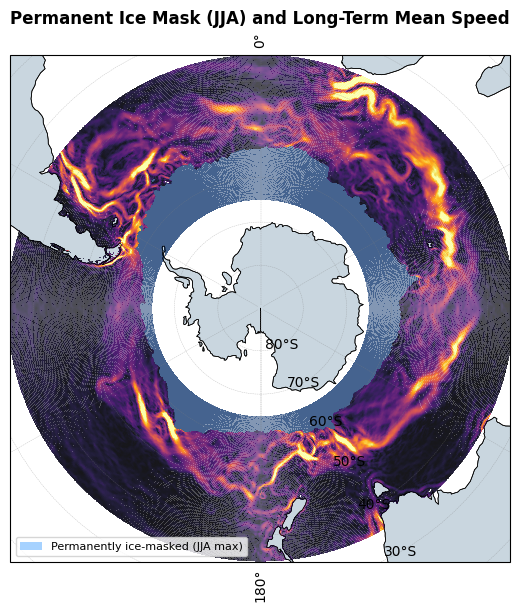

In [6]:
fig = plt.figure(figsize=(14, 6))
ax  = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -35], crs=ccrs.PlateCarree())

speed_ltm = np.sqrt(u_mean_arr**2 + v_mean_arr**2)
ax.pcolormesh(lons_ref, lats_ref, speed_ltm,
              transform=ccrs.PlateCarree(), cmap='inferno', vmin=0, vmax=0.4, alpha=0.7)
ax.pcolormesh(lons_ref, lats_ref, np.where(ice_ever, 1.0, np.nan),
              transform=ccrs.PlateCarree(), cmap='Blues', vmin=0, vmax=1, alpha=0.5)

ax.add_feature(cfeature.LAND, facecolor='#c9d6df', edgecolor='k', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#81c0ff", alpha=0.7, label='Permanently ice-masked (JJA max)'),
], loc='lower left', fontsize=8, frameon=True)
ax.set_title('Permanent Ice Mask (JJA) and Long-Term Mean Speed', fontweight='bold')
plt.tight_layout()
plt.show()